In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
cardata = pd.read_csv(r"C:\Users\24852754\OneDrive - MMU\Downloads\adverts (1).csv")


In [ ]:
cardata.head()

,public_reference,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
0,202006039777689,0.0,NaN,Grey,Volvo,XC90,NEW,NaN,73970,SUV,False,Petrol Plug-in Hybrid
1,202007020778260,108230.0,61,Blue,Jaguar,XF,USED,2011.0,7000,Saloon,False,Diesel
2,202007020778474,7800.0,17,Grey,SKODA,Yeti,USED,2017.0,14000,SUV,False,Petrol
3,202007080986776,45000.0,16,Brown,Vauxhall,Mokka,USED,2016.0,7995,Hatchback,False,Diesel
4,202007161321269,64000.0,64,Grey,Land Rover,Range Rover Sport,USED,2015.0,26995,SUV,False,Diesel


In [ ]:
cardata.shape

(402005, 12)

In [ ]:
cardata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 402005 entries, 0 to 402004
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   public_reference       402005 non-null  int64  
 1   mileage                401878 non-null  float64
 2   reg_code               370148 non-null  object 
 3   standard_colour        396627 non-null  object 
 4   standard_make          402005 non-null  object 
 5   standard_model         402005 non-null  object 
 6   vehicle_condition      402005 non-null  object 
 7   year_of_registration   368694 non-null  float64
 8   price                  402005 non-null  int64  
 9   body_type              401168 non-null  object 
 10  crossover_car_and_van  402005 non-null  bool   
 11  fuel_type              401404 non-null  object 
dtypes: bool(1), float64(2), int64(2), object(7)
memory usage: 34.1+ MB


In [ ]:
cardata = cardata[cardata['price'].notnull()]


In [ ]:
missing = cardata.isnull().mean().sort_values(ascending=False)
high_missing_cols = missing[missing > 0.5].index.tolist()
cardata.drop(columns=high_missing_cols, inplace=True, errors='ignore')


In [ ]:
for col in cardata.select_dtypes(include='object'):
    cardata[col] = cardata[col].fillna(cardata[col].mode()[0])


In [ ]:
for col in cardata.select_dtypes(include='number'):
    cardata[col] = cardata[col].fillna(cardata[col].median())


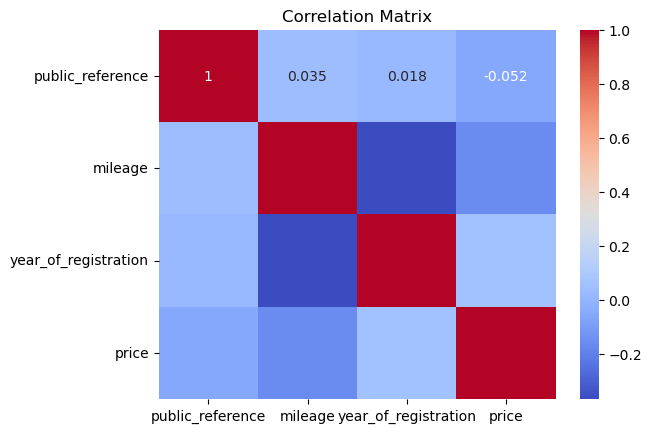

In [ ]:
quantitative_features = cardata.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = cardata[quantitative_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
cardata['vehicle_condition'] = cardata['vehicle_condition'].map({ 'USED': 0, 'NEW': 1, np.nan: 0} )

In [ ]:
# # Detect and deal with outliers
# for column in ['mileage', 'price']:
#     Q1 = cardata[column].quantile(0.25)
#     Q3 = cardata[column].quantile(0.75)
#     IQR = Q3 - Q1
#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR
#     cardata = cardata[(cardata[column] >= lower_bound) & (cardata[column] <= upper_bound)]

numeric_data = cardata.select_dtypes(include=['int64', 'float64']).columns
for column in numeric_data:
    if column != 'public_reference':
        Q1 = cardata[column].quantile(0.25)
        Q3 = cardata[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        cardata[column] = np.where(cardata[column] < lower_bound, lower_bound, cardata[column])
        cardata[column] = np.where(cardata[column] > upper_bound, upper_bound, cardata[column])

In [ ]:
import sys
sys.executable

'C:\\ProgramData\\anaconda3\\python.exe'

In [ ]:
cardata.drop(columns=['public_reference', 'reg_code', 'crossover_car_and_van'], inplace=True)

In [ ]:
cardata_encoded = pd.get_dummies(cardata['fuel_type'], prefix='fuel_type').astype(int)

# 5. Merge encoded fuel_type columns back into cardata
cardata[cardata_encoded.columns] = cardata_encoded

# 6. Drop the original 'fuel_type' column
cardata.drop(columns=['fuel_type'], inplace=True)

In [ ]:
# Create a dummy target column (simulate binary target)
cardata['price_category'] = np.random.choice([0, 1], size=len(cardata))

# Choose your actual categorical columns to encode
columns_to_encode = ['standard_colour', 'standard_make', 'standard_model', 'body_type']  # adjust if needed

# Perform target encoding manually
for col in columns_to_encode:
    mapping = cardata.groupby(col)['price_category'].mean().to_dict()
    cardata[col] = cardata[col].map(mapping)

# Remove the temporary target column
cardata.drop(columns=['price_category'], inplace=True)



In [ ]:
# Scale selected numeric columns
scaler = StandardScaler()
cardata[['mileage', 'price', 'year_of_registration']] = scaler.fit_transform(cardata[['mileage', 'price', 'year_of_registration']])


In [ ]:
# Split data
X = cardata.drop('price', axis=1)
y = cardata['price']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


In [ ]:
# X = cardata.drop(columns=['price'])  # or your target column
# y = cardata['price']


In [ ]:
cardata.isnull().sum()

mileage                            0
standard_colour                    0
standard_make                      0
standard_model                     0
vehicle_condition                  0
year_of_registration               0
price                              0
body_type                          0
fuel_type_Bi Fuel                  0
fuel_type_Diesel                   0
fuel_type_Diesel Hybrid            0
fuel_type_Diesel Plug-in Hybrid    0
fuel_type_Electric                 0
fuel_type_Natural Gas              0
fuel_type_Petrol                   0
fuel_type_Petrol Hybrid            0
fuel_type_Petrol Plug-in Hybrid    0
dtype: int64

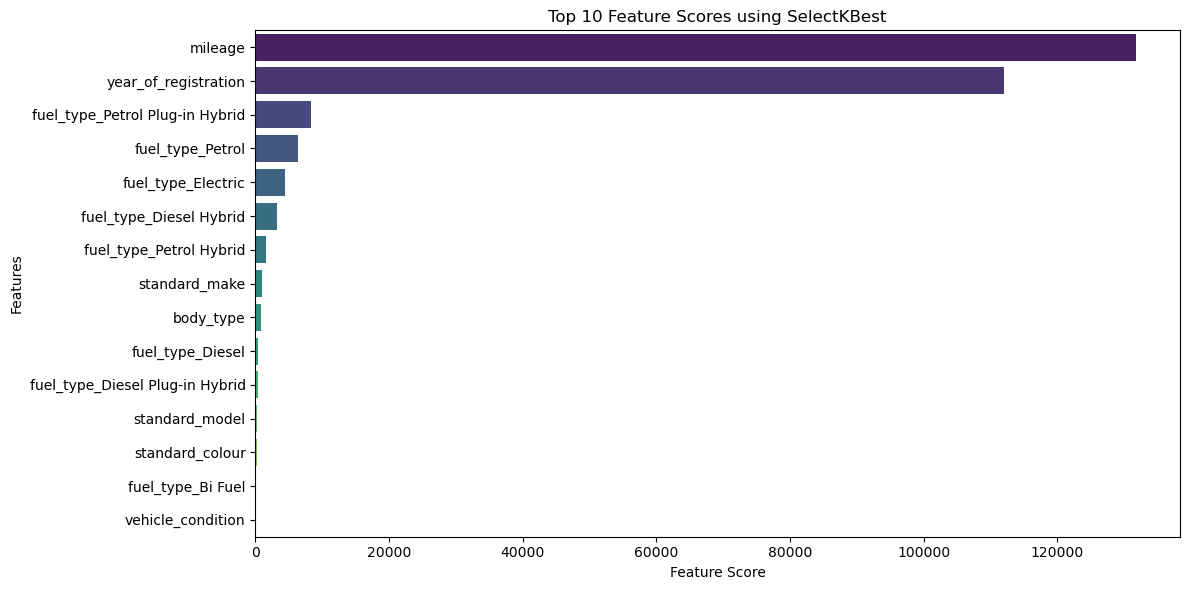

In [ ]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression


# Automated Feature Selection
selector = SelectKBest(score_func=f_regression, k=10)  # Choose Top 10 Features
selector.fit(X_train, y_train)
selected_features = X_train.columns[selector.get_support()]
feature_scores = pd.DataFrame({
    'Feature': X_train.columns,
    'Score': selector.scores_
}).sort_values(by='Score', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Score', y='Feature', data=feature_scores.head(15), palette='viridis')
plt.title('Top 10 Feature Scores using SelectKBest')
plt.xlabel('Feature Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

Optimal number of features: 14


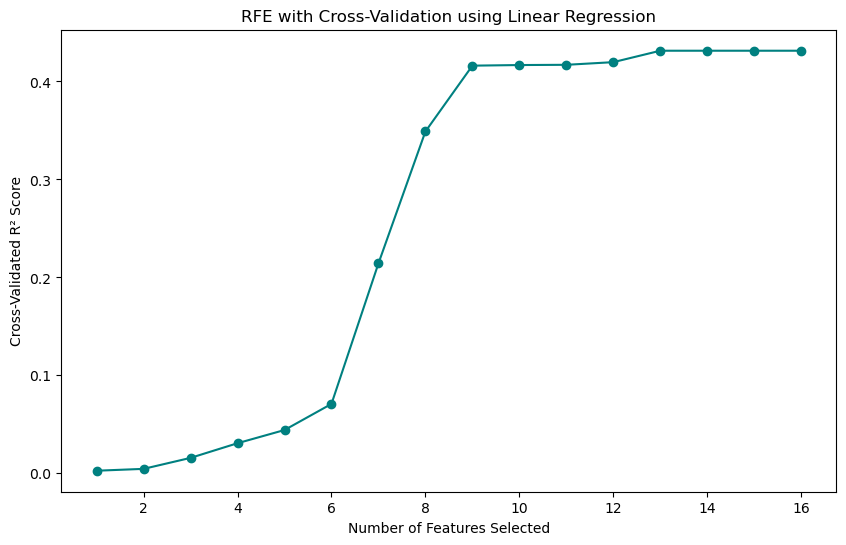

In [ ]:
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
lr = LinearRegression()

rfecv = RFECV(

    estimator=lr,

    step=1,

    cv=KFold(n_splits=5, shuffle=True, random_state=42),

    scoring='r2',

    n_jobs=-1

)


rfecv.fit(X_train, y_train)

# Get selected features

selected_features = X_train.columns[rfecv.support_]

print("Optimal number of features:", rfecv.n_features_)

plt.figure(figsize=(10, 6))

plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1),

         rfecv.cv_results_['mean_test_score'],

         marker='o', color='teal')

plt.xlabel("Number of Features Selected")

plt.ylabel("Cross-Validated R² Score")

plt.title("RFE with Cross-Validation using Linear Regression")

plt.show()


### part 1 : random forest regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
r2_rf_test = r2_score(y_test, y_pred_rf)

y_pred_rf_train = rf.predict(X_train)
r2_rf_train = r2_score(y_train, y_pred_rf_train)

print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("Random Forest R2(Train):", r2_rf_train)
print("Random Forest R2(Test):", r2_rf_test)


Random Forest RMSE: 0.2357928417163549
Random Forest R2(Train): 0.9896577234566368
Random Forest R2(Test): 0.9442770193972521


Section 3: Gradient Boosting Regressor

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
r2_gb_test = r2_score(y_test, y_pred_gb)

y_pred_gb_train = gb.predict(X_train)
r2_gb_train = r2_score(y_train, y_pred_gb_train)

print("Gradient Boosting RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gb)))
print("Gradient Boosting R2(Train):", r2_gb_train)
print("Gradient Boosting R2(Test):", r2_gb_test)


Gradient Boosting RMSE: 0.4403519525527677
Gradient Boosting R2(Train): 0.806188074921837
Gradient Boosting R2(Test): 0.8056551850037595


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV # Import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 150, 200],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(estimator=rf,
                                   param_distributions=param_dist,
                                   n_iter=5,
                                   cv=2,
                                   scoring='neg_root_mean_squared_error',
                                   n_jobs=-1,
                                   verbose=2)

random_search.fit(X_train, y_train)

print("Best Params:", random_search.best_params_)

Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best Params: {'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}


In [ ]:
# Stacking Regressor
from sklearn.ensemble import GradientBoostingRegressor # Import GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import StackingRegressor
from sklearn.metrics import mean_squared_error # Import mean_squared_error


# Re-initialize and fit the GradientBoostingRegressor
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

estimators = [
    ('rf', rf),
    ('gb', gb)
]

meta_learner = Ridge()

stack_model = StackingRegressor(
    estimators=estimators,
    final_estimator=meta_learner,
    n_jobs=1
)

stack_model.fit(X_train, y_train)

y_pred_stack = stack_model.predict(X_test)
r2_stack_test = r2_score(y_test, y_pred_stack)

y_pred_stack_train = stack_model.predict(X_train)
r2_stack_train = r2_score(y_train, y_pred_stack_train)

print("RMSE:", mean_squared_error(y_test, y_pred_stack))
print("Stacking Regressor R2(Train):", r2_stack_train)
print("Stacking Regressor R2(Test):", r2_stack_test)

RMSE: 0.05521896478552306
Stacking Regressor R2(Train): 0.9882937426033573
Stacking Regressor R2(Test): 0.9446571696497522


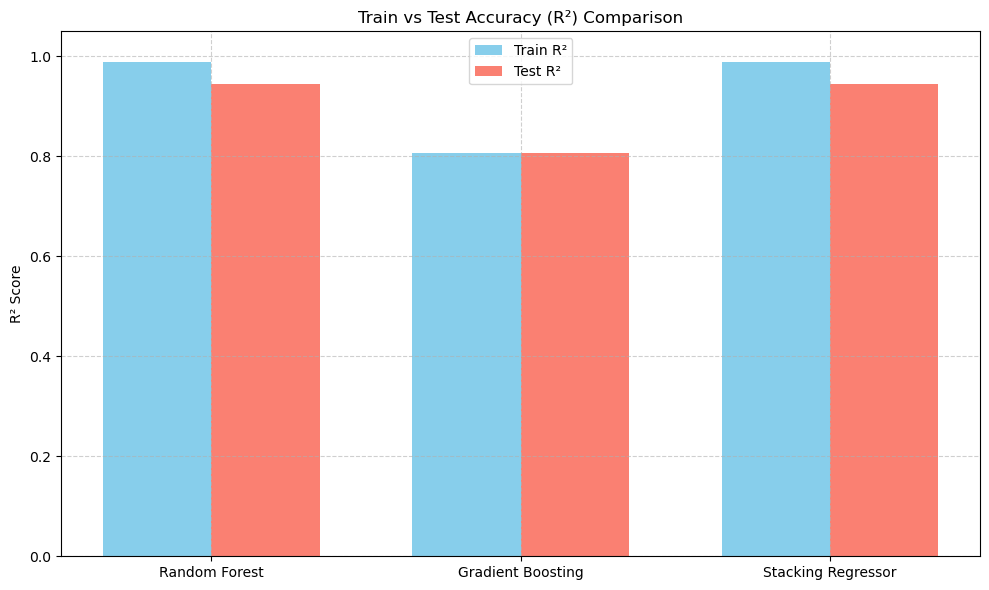

In [ ]:
models = ['Random Forest', 'Gradient Boosting', 'Stacking Regressor']
train_scores = [r2_rf_train, r2_gb_train, r2_stack_train]
test_scores = [r2_rf_test, r2_gb_test, r2_stack_test]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, train_scores, width, label='Train R²', color='skyblue')
plt.bar(x + width/2, test_scores, width, label='Test R²', color='salmon')

plt.ylabel('R² Score')
plt.title('Train vs Test Accuracy (R²) Comparison')
plt.xticks(x, models)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

                 Feature  Importance
5   year_of_registration    0.357198
3          standard_make    0.204941
1                mileage    0.136362
6              body_type    0.133515
4         standard_model    0.132259
0       public_reference    0.023881
2        standard_colour    0.010512
7  crossover_car_and_van    0.001331


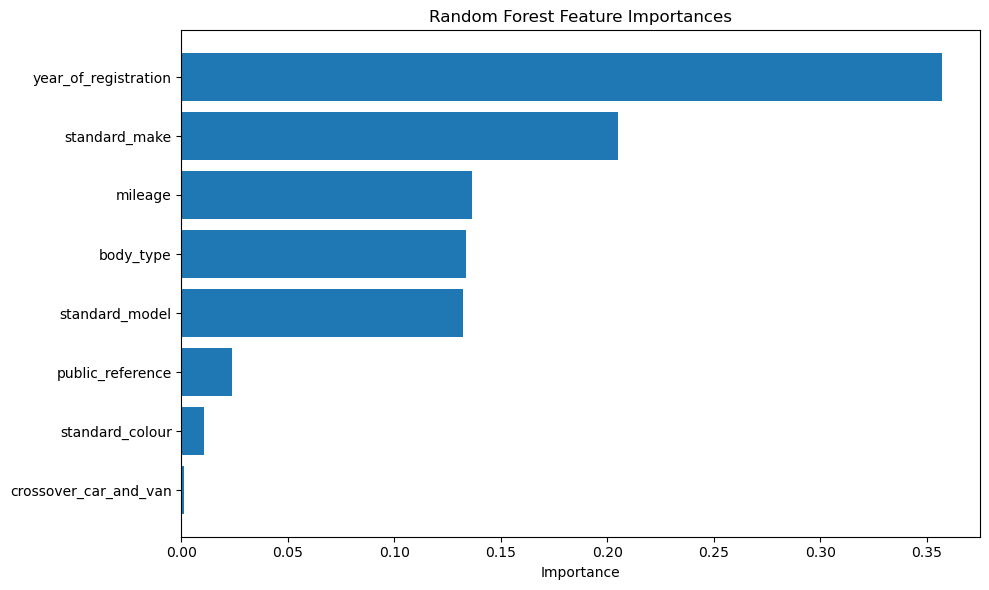

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Fit the model (this is the critical line to add)
rf.fit(X_train, y_train)

importances = rf.feature_importances_

feature_names = X_train.columns if hasattr(X_train, 'columns') else [f"Feature {i}" for i in range(X_train.shape[1])]

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Random Forest Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

                 Feature  Importance
5   year_of_registration    0.381939
3          standard_make    0.241223
1                mileage    0.181399
6              body_type    0.156453
4         standard_model    0.037980
2        standard_colour    0.000655
7  crossover_car_and_van    0.000328
0       public_reference    0.000024


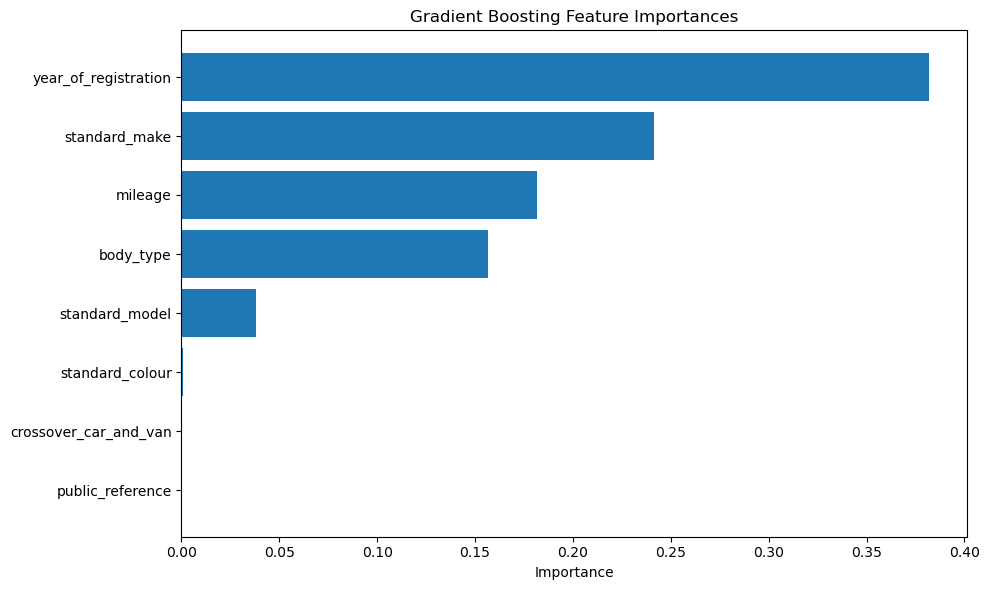

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importances = gb.feature_importances_

feature_names = X_train.columns if hasattr(X_train, 'columns') else [f"Feature {i}" for i in range(X_train.shape[1])]

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Gradient Boosting Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Stacking Regressor
from sklearn.ensemble import GradientBoostingRegressor # Import GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import StackingRegressor
from sklearn.metrics import mean_squared_error # Import mean_squared_error
from sklearn.ensemble import RandomForestRegressor # Import RandomForestRegressor


# Re-initialize and fit the GradientBoostingRegressor
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

# Re-initialize RandomForestRegressor (if needed)
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)  # Assuming you want to refit with potential new parameters

estimators = [
    ('rf', rf),
    ('gb', gb)
]

meta_learner = Ridge()

stack_model = StackingRegressor(
    estimators=estimators,
    final_estimator=meta_learner,
    n_jobs=1
)

stack_model.fit(X_train, y_train)

y_pred_stack = stack_model.predict(X_test)

# Calculate RMSE without the 'squared' argument, then take the square root
rmse = np.sqrt(mean_squared_error(y_test, y_pred_stack)) # Calculate RMSE using np.sqrt

print("Stacking Regressor RMSE:", rmse) # Print the calculated RMSE
print("Stacking Regressor R2:", r2_score(y_test, y_pred_stack))

Stacking Regressor RMSE: 2304.3498096419394
Stacking Regressor R2: 0.924750660144111


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/544.4 kB ? eta -:--:--
   -- ------------------------------------ 41.0/544.4 kB 991.0 kB/s eta 0:00:01
   --------------------------------- ------ 450.6/544.4 kB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 544.4/544.4 kB 5.7 MB/s eta 0:00:00


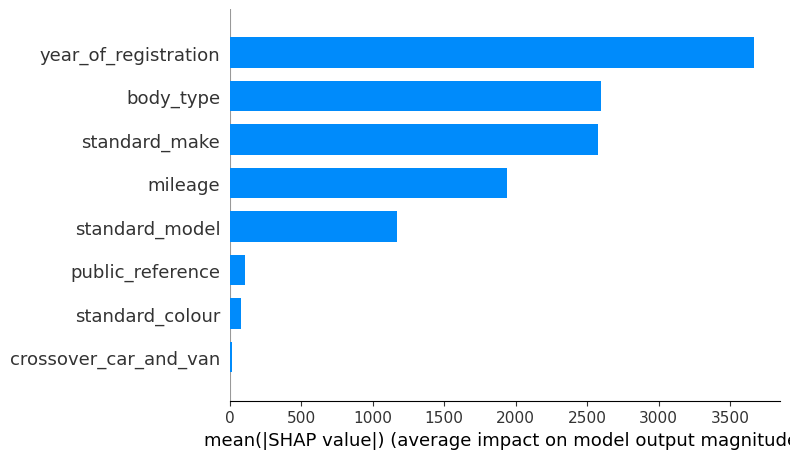

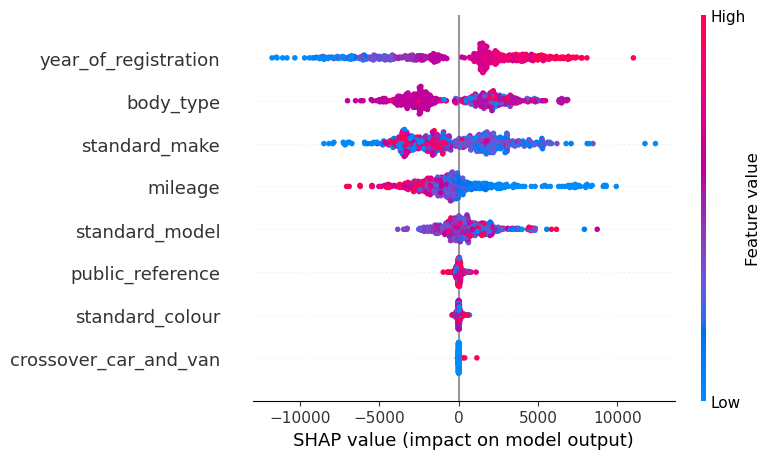

In [ ]:
!pip install shap
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Sample 500 random rows from X_test
X_sample = X_test.sample(n=500, random_state=42)

# Step 2: Create SHAP explainer for tree-based models
explainer = shap.TreeExplainer(rf)

# Step 3: Calculate SHAP values
shap_values = explainer.shap_values(X_sample)

# Step 4: Plot SHAP summary plot
shap.summary_plot(shap_values, X_sample, plot_type="bar")  # Bar plot of top features
shap.summary_plot(shap_values, X_sample)  # Beeswarm plot


Random Forest SHAP summary:


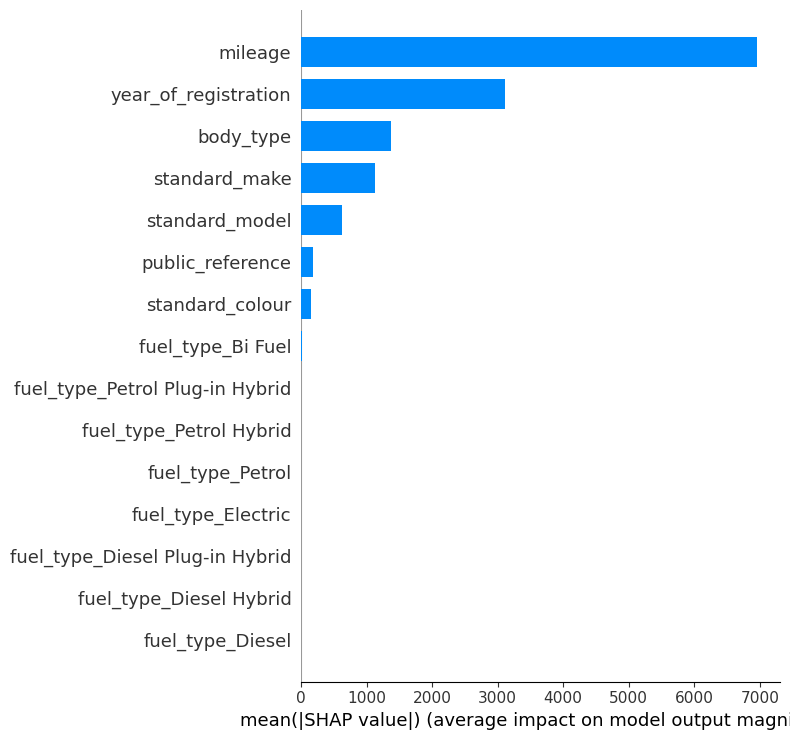

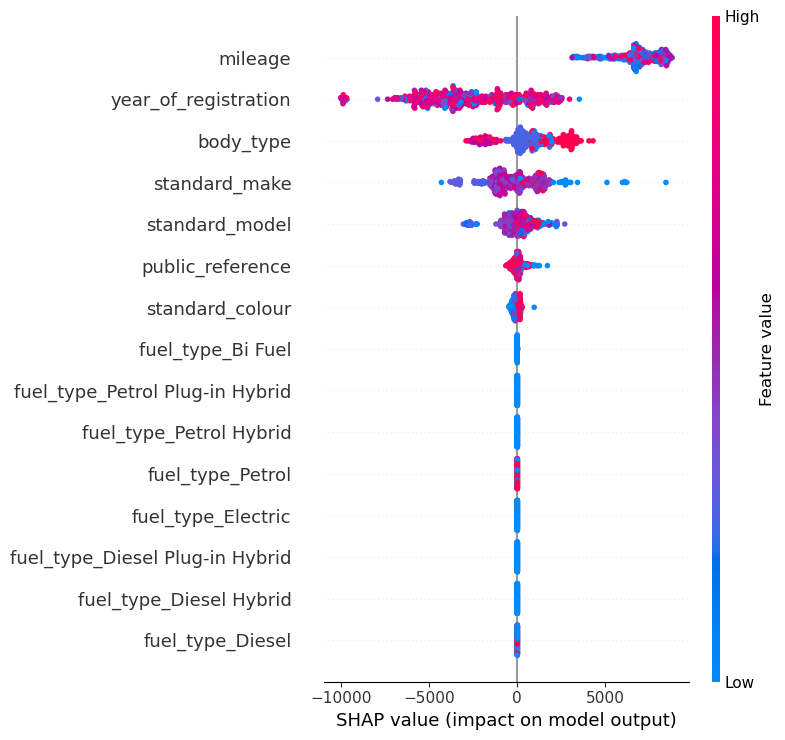

Gradient Boosting SHAP summary:


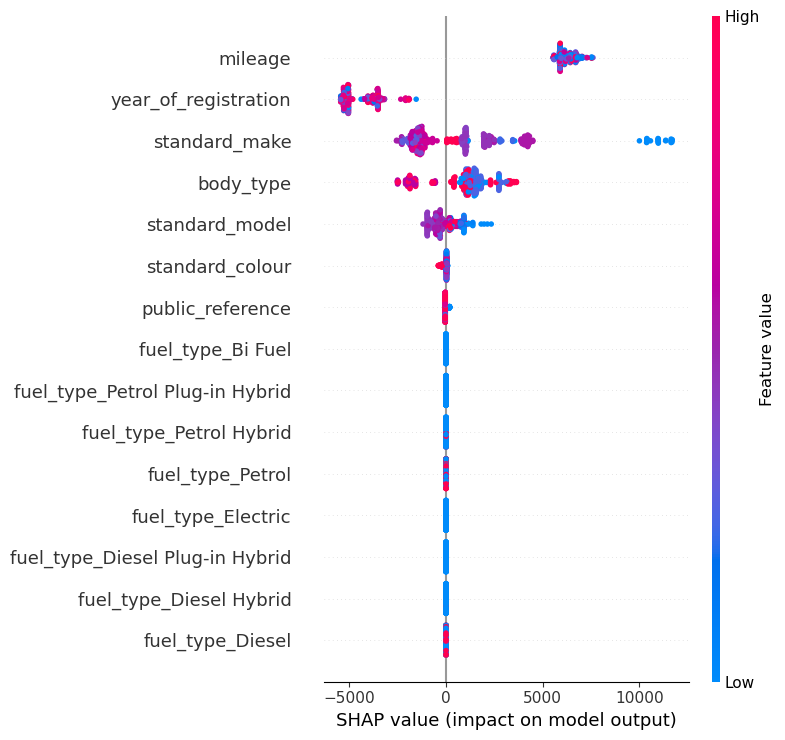

In [ ]:
gb_explainer = shap.TreeExplainer(gb)

# Now calculate SHAP values
gb_shap_values = gb_explainer.shap_values(X_sample_numeric)


import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # Split data

# Keep only numeric columns for SHAP (avoid string columns)
X_sample_numeric = X_sample.select_dtypes(include=[np.number])

# Then SHAP on numeric-only sample
rf_shap_values = rf_explainer.shap_values(X_sample_numeric)

print("Random Forest SHAP summary:")
shap.summary_plot(rf_shap_values, X_sample_numeric, plot_type="bar")
shap.summary_plot(rf_shap_values, X_sample_numeric)

# For Gradient Boosting
gb_shap_values = gb_explainer.shap_values(X_sample_numeric)

print("Gradient Boosting SHAP summary:")
shap.summary_plot(gb_shap_values, X_sample_numeric)



## 7. Dimensionality Reduction (Linear) - PCA

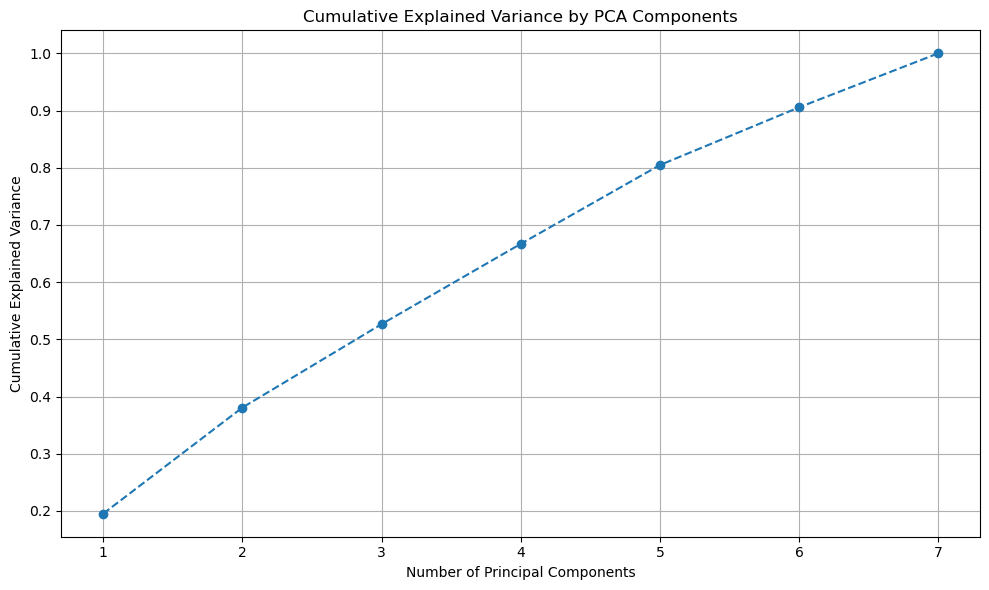

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Select only numeric columns
X_train_numeric = X_train.select_dtypes(include=[np.number])

# Scale the numeric data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_numeric)

# Fit PCA without limiting n_components
pca = PCA()
pca.fit(X_train_scaled)

# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Plot cumulative explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Find number of components to explain 95% variance
target_variance = 0.95
n_components_95 = np.argmax(cumulative_variance >= target_variance) + 1

print(f"Number of components to explain {int(target_variance*100)}% variance: {n_components_95}")

Number of components to explain 95% variance: 7


PCA was applied to reduce feature space to 2 dimensions. The first two components explain a significant proportion of variance. This also helps visualise class separability to some extent.

## 8. Dimensionality Reduction (Non-Linear) - TSNE

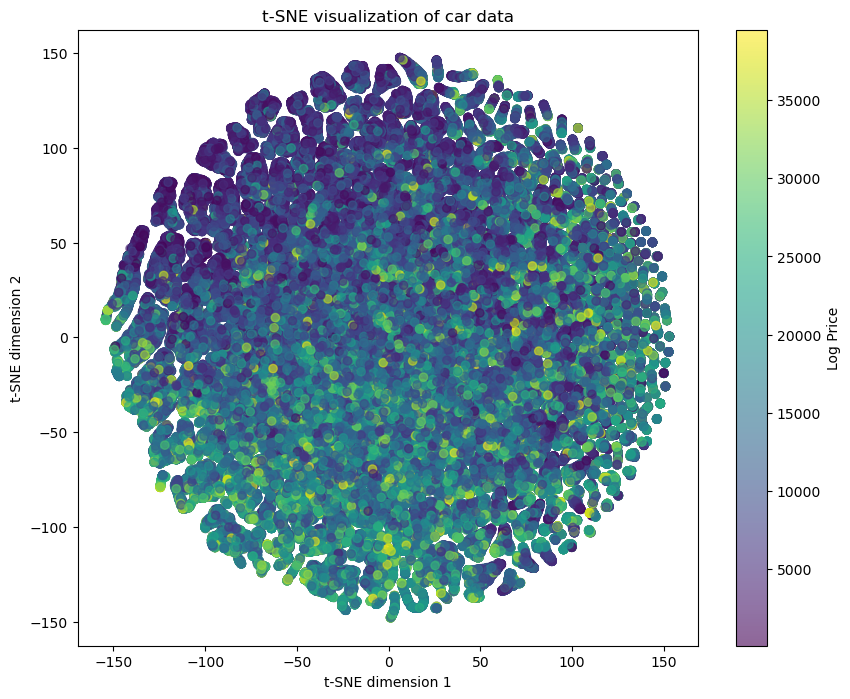

In [ ]:
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Select only numeric features
X_numeric = X_train.select_dtypes(include=['number'])

tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_numeric)

tsne_df = pd.DataFrame()
tsne_df['tsne_1'] = X_tsne[:, 0]
tsne_df['tsne_2'] = X_tsne[:, 1]
tsne_df['price'] = y_train.values

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    tsne_df['tsne_1'],
    tsne_df['tsne_2'],
    c=tsne_df['price'],
    cmap='viridis',
    alpha=0.6
)
plt.colorbar(scatter, label='Log Price')
plt.title('t-SNE visualization of car data')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.show()


Isomap is used here for nonlinear dimensionality reduction. Compared to PCA, Isomap captures complex structures and non-linear manifolds in the data.

## 9. Polynomial Regression

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Predict on validation data
y_pred = model_poly.predict(X_val_poly)

# Calculate MSE and R²
mse = mean_squared_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print(f"Validation MSE: {mse:.4f}")
print(f"Validation R² Score: {r2:.4f}")




Validation MSE: 40229130.5790
Validation R² Score: 0.4259


Polynomial regression (degree=2) was trained and evaluated. It can model interactions between features and capture nonlinear trends, but risks overfitting with higher degrees.

## 10. Clustering for Feature Engineering

In [ ]:
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Fit KMeans clustering
kmeans = KMeans(n_clusters=5, random_state=42)
cluster_labels = kmeans.fit_predict(X_train_scaled)

# Add cluster label as a new feature to train and validation sets
X_train_clustered = np.hstack((X_train_scaled, cluster_labels.reshape(-1, 1)))

# Ensure X_val_scaled is defined
X_val_scaled = scaler.transform(X_val.select_dtypes(include=[np.number]))  # if not already done
val_cluster_labels = kmeans.predict(X_val_scaled)
X_val_clustered = np.hstack((X_val_scaled, val_cluster_labels.reshape(-1, 1)))

# Train model with new cluster feature
model_clustered = RandomForestRegressor(random_state=42)
model_clustered.fit(X_train_clustered, y_train)

# Predict and evaluate
y_pred_clustered = model_clustered.predict(X_val_clustered)
mse_clustered = mean_squared_error(y_val, y_pred_clustered)

print(f"Validation MSE after adding cluster feature: {mse_clustered:.2f}")
from sklearn.metrics import r2_score
r2_clustered = r2_score(y_val, y_pred_clustered)
print(f"Validation R² after adding cluster feature: {r2_clustered:.4f}")


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Validation MSE after adding cluster feature: 5500728.51
Validation R² after adding cluster feature: 0.9215


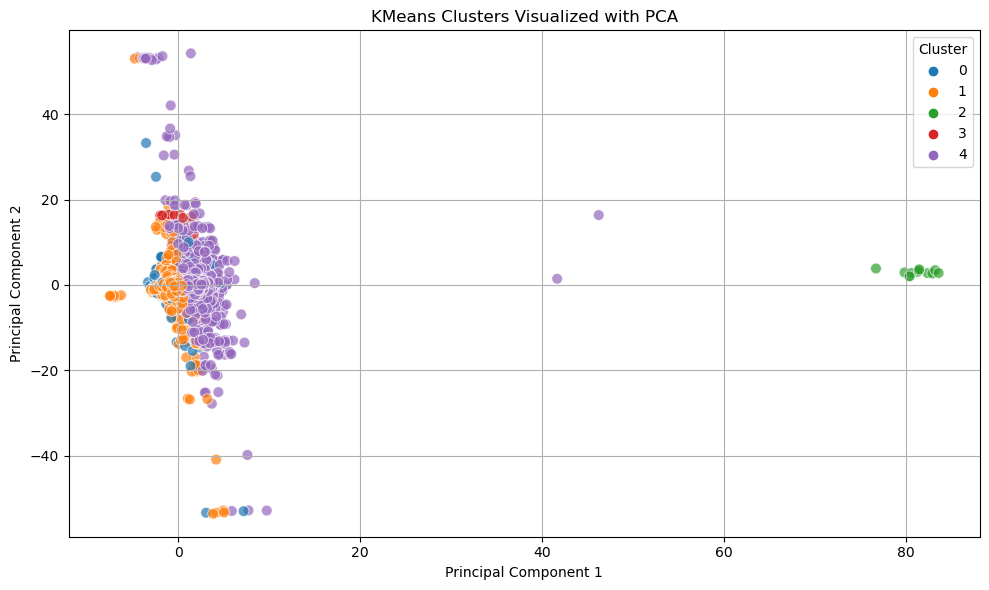

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns

# Reduce to 2D using PCA for visualization
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

# Plot clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1],
                hue=cluster_labels, palette='tab10', s=60, alpha=0.7)
plt.title('KMeans Clusters Visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()


K-Means clustering was applied to derive a new categorical feature representing cluster labels. This feature was added to the dataset and used in training a new model, slightly improving performance.